# GPT Finally!

## 1. But what really stand for GPT?
<div class='alert alert-block alert-info'>
A Generative Pre‑trained Transformer (GPT) is a type of large language model built on the transformer architecture, trained on massive amounts of text data to learn patterns of language. After pre‑training, it can generate coherent text, answer questions, and perform many language tasks by predicting the next word in a sequence.
</div>

## 2. Configuration
Here is the configuration of GPT-2 (124M parameters). Those are `hyperparameters` that can be played with.

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

## 3. **THE BUILDING BLOCKS OF GPT**
- ## Layer Normalization


In [ ]:
import torch
import torch.nn as nn

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        # They are registered to be model parameters, that the optimizer will update them while training
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.ones(emb_dim))

    def forward(self,x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x-mean)/torch.sqrt(var+self.eps) #Avoid division by 0.
        return self.scale * norm_x + self.shift

It basically changes the **variance** of batch input to 1 and the **mean** to 0. 

This can help alleviate the effect of **gradient explosion** or **vanishing gradient**, also speeding up **convergence**.

`torch.nn.Parameter` is a special kind of tensor in PyTorch that tells the framework *“this is a trainable parameter of the model.”* When you assign a `Parameter` inside an `nn.Module`, it is automatically registered so that `model.parameters()` and optimizers know to update it during training.  

In the `LayerNorm` example, the `scale` (γ) and `shift` (β) are defined as `Parameter`s. That means they will be learned during training, allowing the model to adjust the normalized values flexibly instead of always keeping them fixed. Without `Parameter`, they would just be static tensors and never change.

-  ## Activation Function

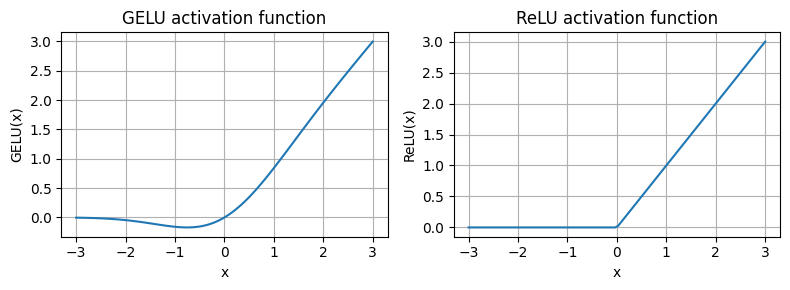


<div class="alert alert-block alert-info">

As we can see in the resulting plot, ReLU is a piecewise linear function that
outputs the input directly if it is positive; otherwise, it outputs zero. 

GELU is a smooth, nonlinear function that approximates ReLU but with a non-zero gradient for negative values.
</div>

<div class="alert alert-block alert-warning">

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties
during training, as it allows for more nuanced adjustments to the model's parameters. 

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder,
especially in networks that are very deep or have complex architectures. 

Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output
for negative values. 

This characteristic means that during the training process, neurons that
receive negative input can still contribute to the learning process, albeit to a lesser extent
than positive inputs.

</div>

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,x):
        return 0.5*x*(
            1 + torch.tanh(
                torch.sqrt(
                    (torch.tensor(2/torch.pi))
                ) * (x + 0.044715 * torch.pow(x,3))
            )
        )

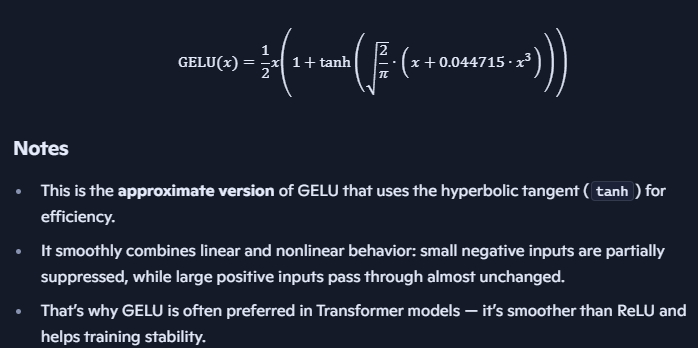

- ## Feed Forward Neural Network

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]), # Expansion
            GELU(), # Activatoin
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]) # Contraction
        )
    def forward(self,x):
        return self.layers(x)

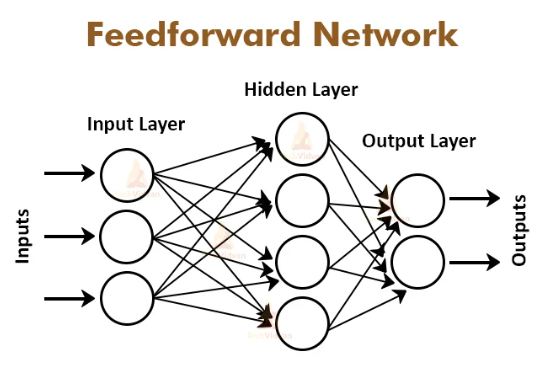


Feed forward neural network **expands** the input dimension as hidden layer(s)(one hidden layer, 4x dimensions in this case), and then **contract** back (into the input dimension in this case).

This allows the model a **rich exploration space**.

- ## Residual Connection
Residual connection means a direct gradient addition from the previous input layer to the new layer, which can prevent any gradient vanishing.

Let's start with an example network.

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output # Residual connection
            else:
                x = layer_output     # No residual connection
        return x

Creating instances of two networks:
- one with shortcut connection
- one without

In [ ]:
sample_input = torch.tensor([[1. , 0., -1.]])
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes =[3,3,3,3,3,1], use_shortcut=False
)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes =[3,3,3,3,3,1], use_shortcut=True
)

Creating a function to represent gradients using MSE loss function:

In [ ]:
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the output to the target
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # print the mean absolute value of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [ ]:

print_gradients(model_without_shortcut, sample_input)
print("\n")
print_gradients(model_with_shortcut, sample_input)


layers.0.0.weight has gradient mean of 9.416165994480252e-05
layers.1.0.weight has gradient mean of 0.0003594491572584957
layers.2.0.weight has gradient mean of 0.0004584027046803385
layers.3.0.weight has gradient mean of 0.0008616186678409576
layers.4.0.weight has gradient mean of 0.04295576736330986


layers.0.0.weight has gradient mean of 0.004125973209738731
layers.1.0.weight has gradient mean of 0.003839152166619897
layers.2.0.weight has gradient mean of 0.0006038391147740185
layers.3.0.weight has gradient mean of 0.0031524791847914457
layers.4.0.weight has gradient mean of 0.0205680038779974


<div class="alert alert-block alert-info">
As we can see based on the output of the print_gradients function, the gradients become
smaller as we progress from the last layer (layers.4) to the first layer (layers.0), which
is a phenomenon called the vanishing gradient problem.
    
</div>

### Why backward pass to calculate gradient?

While training layers of neural networks, we want to know how much extent the output is different than desired value. So usually a loss function is implemented to see the difference between desired output and input.

In mathematics we know that in order to solve the gradient of a composite function, we have to use `chain rule`. In machine learning, each intermediate gradient can be repeated to calculate the next gradient using partial derivative of the output layer to one specific parameters. We have to continuously calculate partial derivatives until we reach the first parameter. This is called `backpropagation`.

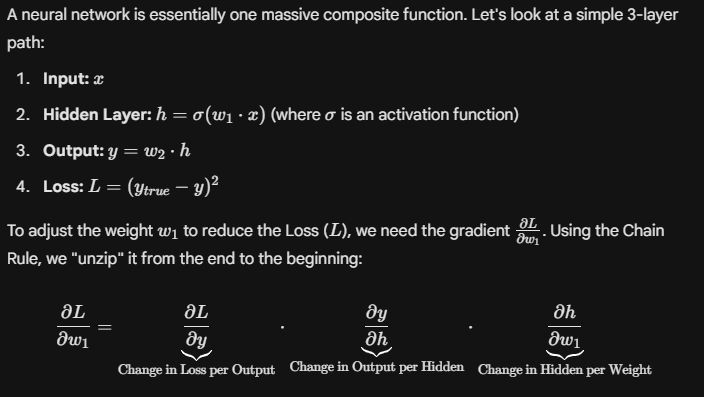

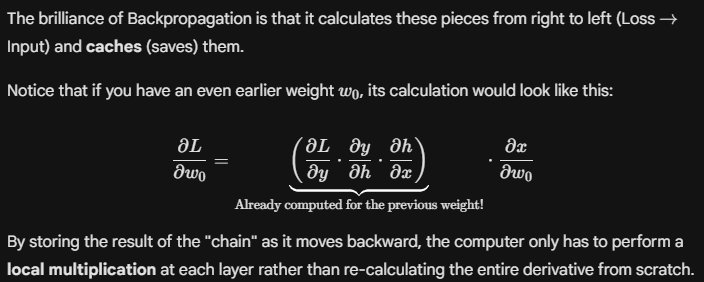

- ## MultiHead Attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match the desired output dim
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) # Linear layer to combine head inputs
        self.dropout = nn.Dropout(dropout) # Floor division
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal = 1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_key(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a 'num_heads' dimension
        # Unroll the last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3) # Dot product for each head
        # (b, num_heads, num_tokens, num_tokens)

        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1,2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        # Combine all heads back into one unified representation.

        return context_vec



## 4. The Transformer Block


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Residual connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)             # Shape (batch_size, num_tokens, emb_size)
        x = self.drop_shortcut(x)
        x = x + shortcut            # Add the original input back

        # Residual connection for feedforward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        # creates a sequential stack of TransformerBlock modules equal to the number of layers specified in cfg. 
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"]) #bias?
        '''a linear output head without bias is defined, which
        projects the transformer's output into the vocabulary space of the tokenizer to generate
        logits for each token in the vocabulary.'''

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds+pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

<div class="alert alert-block alert-success">
Let's now initialize the 124 million parameter GPT model using the GPT_CONFIG_124M
dictionary we pass into the cfg parameter and feed it with the batch text input.
</div>

In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

out = model(batch)
print("Input batch: \n", batch)
print("\nOutput shape:", out.shape)
print(out)

<div class="alert alert-block alert-info">

As we can see, the output tensor has the shape [2, 4, 50257], since we passed in 2 input
texts with 4 tokens each. The last dimension, 50,257, corresponds to the vocabulary size of
the tokenizer. In the next section, we will see how to convert each of these 50,257-
dimensional output vectors back into tokens.
    
</div>

<div class="alert alert-block alert-success">
Using the numel() method, short for "number of elements," we can collect the total
number of parameters in the model's parameter tensors:
</div>

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

<div class="alert alert-block alert-danger">
Earlier, we spoke of initializing a 124
million parameter GPT model, so why is the actual number of parameters 163 million, as
shown in the preceding code output?
</div>
<div class="alert alert-block alert-warning">
    
The reason is a concept called weight tying that is used in the original GPT-2
architecture, which means that the original GPT-2 architecture is reusing the weights from
the token embedding layer in its output layer. 

To understand what this means, let's take a
look at the shapes of the token embedding layer and linear output layer that we initialized
on the model via the GPTModel earlier:

</div>


In [ ]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

<div class="alert alert-block alert-info">

As we can see based on the print outputs, the weight tensors for both these layers have the
same shape
</div>

<div class="alert alert-block alert-success">
The token embedding and output layers are very large due to the number of rows for the
50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from
the total GPT-2 model count according to the weight tying:
</div>

In [ ]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

<div class="alert alert-block alert-info">

As we can see, the model is now only 124 million parameters large, matching the original
size of the GPT-2 model.
</div>

<div class="alert alert-block alert-warning">
    
Weight tying reduces the overall memory footprint and computational complexity of the
model. However, in my experience, using separate token embedding and output layers
results in better training and model performance; hence, we are using separate layers in
our GPTModel implementation. The same is true for modern LLMs.

</div>
<div class="alert alert-block alert-success">
Lastly, let us compute the memory requirements of the 163 million parameters in our
GPTModel object:
</div>


In [ ]:
total_size_bytes = total_params * 4 #A
total_size_mb = total_size_bytes / (1024 * 1024) #B
print(f"Total size of the model: {total_size_mb:.2f} MB")

<div class="alert alert-block alert-warning">
    
In conclusion, by calculating the memory requirements for the 163 million parameters in
our GPTModel object and assuming each parameter is a 32-bit float taking up 4 bytes, we
find that the total size of the model amounts to 621.83 MB, illustrating the relatively large
storage capacity required to accommodate even relatively small LLMs.

</div>
<div class="alert alert-block alert-warning">
    
In this section, we implemented the GPTModel architecture and saw that it outputs
numeric tensors of shape [batch_size, num_tokens, vocab_size]. In the next section,
we will write the code to convert these output tensors into text.

</div>

## 5. Generating text from output tokens